In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
df = sns.load_dataset('penguins')
import matplotlib.pyplot as plt

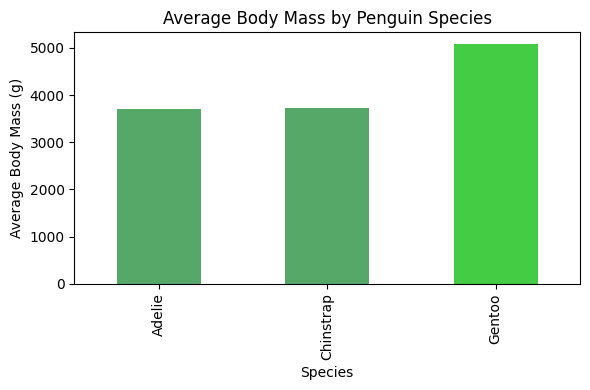

In [29]:
avg_mass = df.groupby('species')['body_mass_g'].mean()

plt.figure(figsize=(6,4))
avg_mass.plot(kind='bar', color=['#55A868','#55A868','#44CC44'])
plt.xlabel('Species')
plt.ylabel('Average Body Mass (g)')
plt.title('Average Body Mass by Penguin Species')
plt.tight_layout()
plt.show()

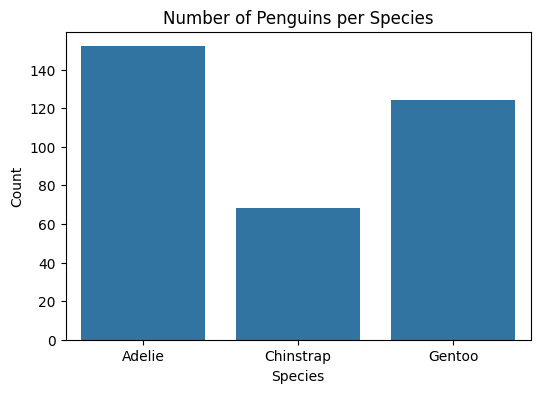

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.title('Number of Penguins per Species')
plt.show()

the most common specie is Adelie penguins with a count of 150, and the least common is Chinstrap with a count of 70

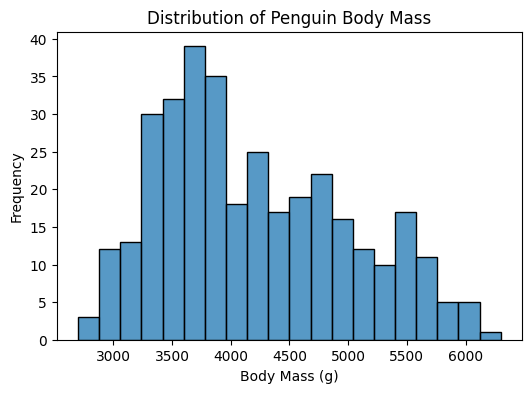

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(df['body_mass_g'], bins=20)
plt.xlabel('Body Mass (g)')
plt.ylabel('Frequency')
plt.title('Distribution of Penguin Body Mass')
plt.show()

the histogram is right skewed as we can see its tail is towards the right adn peak is towards the left,most penguins cluster in the 3000-4500g range

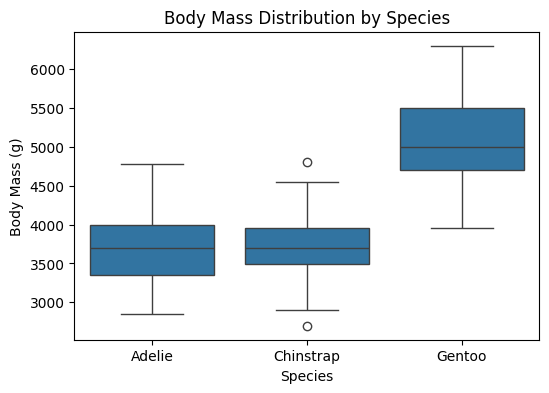

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='species', y='body_mass_g')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.title('Body Mass Distribution by Species')
plt.show()

the chinstrap species have two outliers.

In [33]:
Q1 = df['body_mass_g'].quantile(0.25)
Q3 = df['body_mass_g'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['body_mass_g'] < lower) | (df['body_mass_g'] > upper)]
print(len(outliers))

0


the outliers don't match as using IQR we are looking at th complete data and in the box plot we were looking at their individual columns.

In [34]:
from scipy import stats

df['zscore'] = stats.zscore(df['body_mass_g'])
outliers_z = df[df['zscore'].abs() > 3]
print(len(outliers_z))

0


yes its the same.

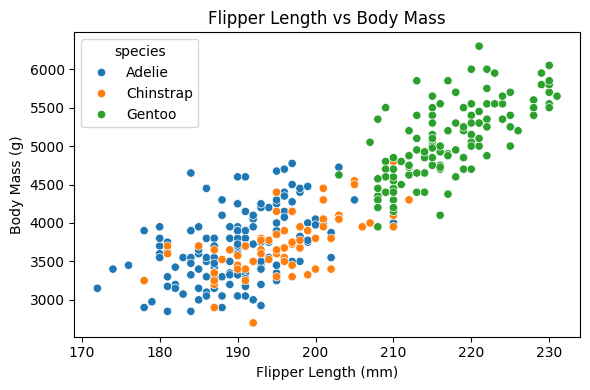

In [35]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title('Flipper Length vs Body Mass')
plt.tight_layout()
plt.show()

we can show that the chinstrap penguins have almost the same body mass and at the same mass they have a little longer flipper lengths, Whereas the Gentoo penguins have a significantly larger bodymass and larger flipper lengths

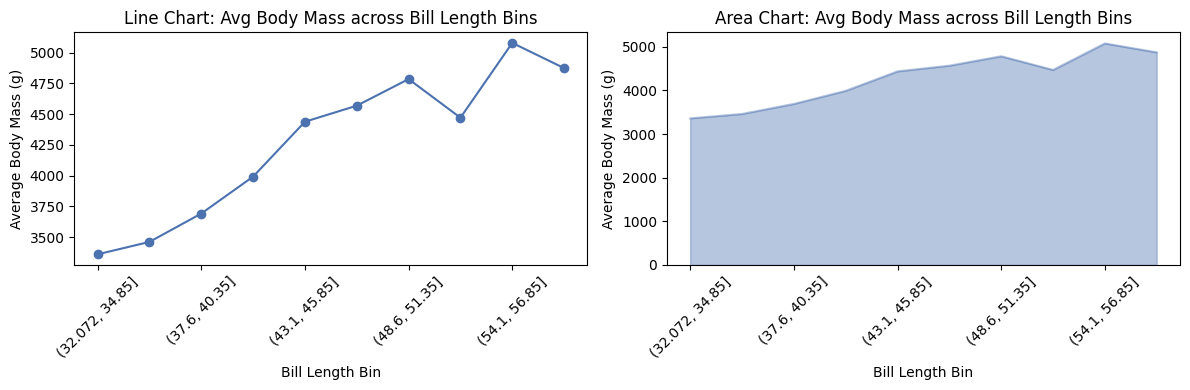

In [36]:
df_sorted = df.sort_values('bill_length_mm')
df_sorted['bill_length_bin'] = pd.cut(df_sorted['bill_length_mm'], bins=10)
trend = df_sorted.groupby('bill_length_bin', observed=True)['body_mass_g'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12,4))

trend.plot(kind='line', marker='o', ax=axes[0], color='#4C72B0')
axes[0].set_title('Line Chart: Avg Body Mass across Bill Length Bins')
axes[0].set_xlabel('Bill Length Bin')
axes[0].set_ylabel('Average Body Mass (g)')
axes[0].tick_params(axis='x', rotation=45)

trend.plot(kind='area', ax=axes[1], color='#4C72B0', alpha=0.4)
axes[1].set_title('Area Chart: Avg Body Mass across Bill Length Bins')
axes[1].set_xlabel('Bill Length Bin')
axes[1].set_ylabel('Average Body Mass (g)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Both charts show the same increasing trend, heavier body mass associates with longer bills,but the area chart's shaded fill visually emphasizes magnitude/accumulation, making the rise look more dramatic, while the plain line chart communicates only the direction and rate of change without that added visual weight.

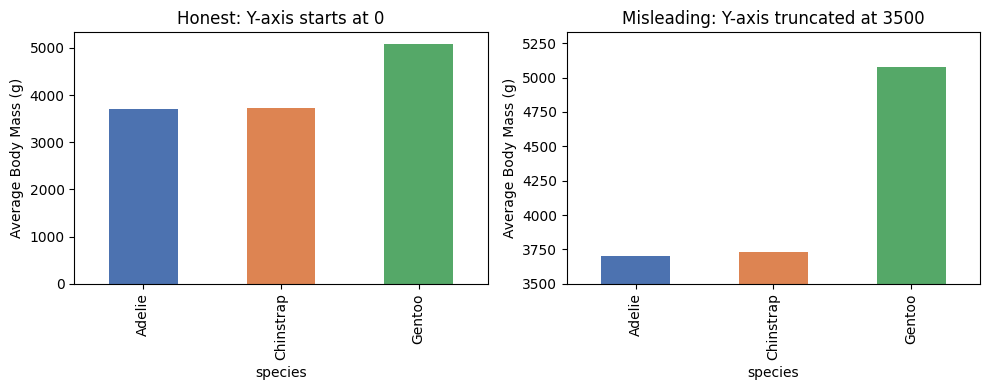

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

avg_mass.plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Honest: Y-axis starts at 0')
axes[0].set_ylabel('Average Body Mass (g)')

avg_mass.plot(kind='bar', ax=axes[1], color=['#4C72B0','#DD8452','#55A868'])
axes[1].set_ylim(bottom=3500)
axes[1].set_title('Misleading: Y-axis truncated at 3500')
axes[1].set_ylabel('Average Body Mass (g)')

plt.tight_layout()
plt.show()

In the honest version, the difference between species looks modest — all three bars are roughly comparable in height. In the truncated version, Gentoo's bar looks dramatically taller than Adelie's and Chinstrap's — visually implying Gentoo penguins are several times heavier, when in reality they're only about 35–37% heavier. The underlying numbers are identical in both charts; only the y-axis starting point changed, which shows how truncating an axis can badly distort the reader's sense of how much difference actually exists between categories.